In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

SHARED_PATH = "/content/drive/MyDrive/Research_Project_2026"
os.environ['KAGGLE_CONFIG_DIR'] = SHARED_PATH

%cd {SHARED_PATH}

# path to images
TRAINING_DATA_PATH = f"{SHARED_PATH}/dataset/Training"
TESTING_DATA_PATH = f"{SHARED_PATH}/dataset/Testing"

Mounted at /content/drive
/content/drive/MyDrive/Research_Project_2026


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
from torchvision import models
import torch.optim as optim


In [ ]:
!pip install imutils

In [ ]:
!pip install opencv-python-headless imutils

In [ ]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np
from PIL import Image
from collections import deque

class CropBrainContour(object):
    def gaussian_blur(self, img_np, rows, cols):
        kernel = (1/16) * np.array([
          [1, 2, 1],
          [2, 4, 2],
          [1, 2, 1]
          ], dtype=np.float64)


        temp = img_np.astype(np.float64)

        blurred = cv2.filter2D(temp, -1, kernel)

        return blurred.astype(np.uint8)

    def threshold(self, img_np, rows, cols, thresh_val=45):
        thresh = np.zeros((rows, cols), dtype=np.uint8)
        for y in range(rows):
            for x in range(cols):
                if img_np[y, x] > thresh_val:
                    thresh[y, x] = 255
                else:
                    thresh[y, x] = 0
        return thresh

    def erode(self, img_np, rows, cols, iterations=1):
        current = img_np
        for _ in range(iterations):
            next_img = np.zeros((rows, cols), dtype=np.uint8)
            for y in range(rows):
                for x in range(cols):
                    min_val = 255
                    # 3x3 Minimum filter
                    for ky in [-1, 0, 1]:
                        for kx in [-1, 0, 1]:
                            ny = y + ky
                            nx = x + kx
                            # Out of bounds is treated as 255 (white) for erosion padding
                            if 0 <= ny < rows and 0 <= nx < cols:
                                val = current[ny, nx]
                            else:
                                val = 255
                            if val < min_val:
                                min_val = val
                    next_img[y, x] = min_val
            current = next_img
        return current

    def dilate(self, img_np, rows, cols, iterations=2):
        current = img_np
        for _ in range(iterations):
            next_img = np.zeros((rows, cols), dtype=np.uint8)
            for y in range(rows):
                for x in range(cols):
                    max_val = 0
                    # 3x3 Maximum filter
                    for ky in [-1, 0, 1]:
                        for kx in [-1, 0, 1]:
                            ny = y + ky
                            nx = x + kx
                            # Out of bounds is treated as 0 (black) for dilation padding
                            if 0 <= ny < rows and 0 <= nx < cols:
                                val = current[ny, nx]
                            else:
                                val = 0
                            if val > max_val:
                                max_val = val
                    next_img[y, x] = max_val
            current = next_img
        return current

    def find_largest_contour(self, img_np, rows, cols):
        visited = np.zeros((rows, cols), dtype=bool)
        max_area = 0
        best_bbox = None

        for r in range(rows):
            for c in range(cols):
                if img_np[r, c] == 255 and not visited[r, c]:
                    # Breadth-First Search (BFS) to find connected components
                    queue = deque([(r, c)])
                    visited[r, c] = True
                    area = 0

                    min_y, max_y = r, r
                    min_x, max_x = c, c

                    while queue:
                        cy, cx = queue.popleft()
                        area += 1

                        if cy < min_y: min_y = cy
                        if cy > max_y: max_y = cy
                        if cx < min_x: min_x = cx
                        if cx > max_x: max_x = cx

                        # Check 8-connected neighbors
                        for dy in [-1, 0, 1]:
                            for dx in [-1, 0, 1]:
                                if dy == 0 and dx == 0:
                                    continue # Skip the center pixel
                                ny, nx = cy + dy, cx + dx
                                if 0 <= ny < rows and 0 <= nx < cols:
                                    if img_np[ny, nx] == 255 and not visited[ny, nx]:
                                        visited[ny, nx] = True
                                        queue.append((ny, nx))
                    if area > max_area:
                        max_area = area
                        best_bbox = (min_y, max_y, min_x, max_x)

        return best_bbox

    def __call__(self, img):
        img_cv2 = np.array(img)
        img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_RGB2BGR)
        gray_np = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY)

        rows, cols = gray_np.shape

        if rows == 0 or cols == 0:
            return img

        blurred = self.gaussian_blur(gray_np, rows, cols)
        thresh = self.threshold(blurred, rows, cols, thresh_val=15)
        eroded = self.erode(thresh, rows, cols, iterations=1)
        dilated = self.dilate(eroded, rows, cols, iterations=2)


        # 3. Find Bounding Box
        bbox = self.find_largest_contour(dilated, rows, cols)

        if bbox is not None:
            min_y, max_y, min_x, max_x = bbox
            img_cv2 = img_cv2[min_y:max_y+1, min_x:max_x+1]

        return Image.fromarray(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))

Removes background noise and text by isolating the largest connected brain mass, ensuring the model focuses only on relevant anatomical structures.

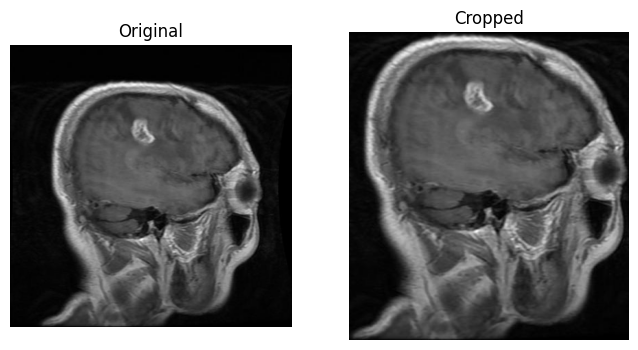

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

cropper = CropBrainContour()

sample_image_path = os.path.join(TRAINING_DATA_PATH, "Tr-gl_5.jpg")

sample_image_path = os.path.join(TRAINING_DATA_PATH, "glioma", "Tr-gl_5.jpg")

original_img = Image.open(sample_image_path).convert("RGB")
cropped_img = cropper(original_img)

# 5. Show them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(original_img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cropped_img)
axes[1].set_title("Cropped")
axes[1].axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np
from PIL import Image

class Sobel(object):
    def __call__(self, img):
        img_np = np.array(img)

        if len(img_np.shape) == 3:
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np

        kernel_x = np.array([[-1, 0, 1],
                             [-2, 0, 2],
                             [-1, 0, 1]])
        kernel_y = np.array([[-1, -2, -1],
                             [0, 0, 0],
                             [1, 2, 1]])

        temp = gray.astype(np.float64)
        temp /= 255.0

        Gx = cv2.filter2D(temp, -1, kernel_x)
        Gy = cv2.filter2D(temp, -1, kernel_y)
        G = np.sqrt(np.square(Gx) + np.square(Gy))

        G = np.clip(G * 255, 0, 255).astype(np.uint8)

        return Image.fromarray(cv2.cvtColor(G, cv2.COLOR_GRAY2RGB))

Calculates horizontal and vertical intensity gradients to highlight the structural boundaries and edges of potential tumor masses.

In [ ]:
class LaplacianOfGaussian(object):
    def __call__(self, img):
        img_np = np.array(img)

        kernel_blur = (1/16.0) * np.array([
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1]
        ])

        laplacian_filter = np.array([
            [0, 1, 0],
            [1, -4, 1],
            [0, 1, 0]
        ])

        temp = img_np.astype(np.float64)

        blurred_img = cv2.filter2D(temp, -1, kernel_blur)

        # Laplacian Filter
        mask = cv2.filter2D(blurred_img, -1, laplacian_filter)

        # Sharpen the Image
        sharpened_image = temp - mask
        sharpened_image = np.clip(sharpened_image, 0, 255).astype(np.uint8)

        return Image.fromarray(sharpened_image)


class CLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def _clahe_single_channel(self, channel):
        rows, cols = channel.shape
        tile_h, tile_w = self.tile_grid_size
        # divide the image into small tiles (8×8 grid)
        n_tiles_y = rows // tile_h
        n_tiles_x = cols // tile_w

        # Clip histogram and compute CDF per tile
        tile_cdfs = {}
        for ty in range(n_tiles_y):
            for tx in range(n_tiles_x):
                y0, y1 = ty * tile_h, (ty + 1) * tile_h
                x0, x1 = tx * tile_w, (tx + 1) * tile_w
                tile = channel[y0:y1, x0:x1]

                # Build histogram
                hist = np.zeros(256, dtype=np.float64)
                for val in tile.flatten():
                    hist[val] += 1

                # Clip histogram
                n_pixels = tile_h * tile_w
                clip_val = self.clip_limit * n_pixels / 256.0
                excess = 0.0
                for i in range(256):
                    if hist[i] > clip_val:
                        excess += hist[i] - clip_val
                        hist[i] = clip_val
                redistribute = excess / 256.0
                for i in range(256):
                    hist[i] += redistribute

                # Compute CDF
                cdf = np.cumsum(hist)
                cdf_min = cdf[cdf > 0][0]
                lut = np.clip(
                    np.round((cdf - cdf_min) / (n_pixels - cdf_min) * 255),
                    0, 255
                ).astype(np.uint8)
                tile_cdfs[(ty, tx)] = lut

        # Bilinear interpolation between tile LUTs (look up table, array of input to output mappings)
        output = np.zeros_like(channel)
        for y in range(rows):
            for x in range(cols):
                # Find surrounding tile centers
                ty_f = (y - tile_h / 2.0) / tile_h
                tx_f = (x - tile_w / 2.0) / tile_w
                ty0 = int(np.floor(ty_f))
                tx0 = int(np.floor(tx_f))
                ty1 = ty0 + 1
                tx1 = tx0 + 1

                # Clamp to valid tile indices
                ty0 = max(0, min(ty0, n_tiles_y - 1))
                ty1 = max(0, min(ty1, n_tiles_y - 1))
                tx0 = max(0, min(tx0, n_tiles_x - 1))
                tx1 = max(0, min(tx1, n_tiles_x - 1))

                wy = ty_f - np.floor(ty_f)
                wx = tx_f - np.floor(tx_f)

                v = channel[y, x]
                val = (
                    (1 - wy) * (1 - wx) * tile_cdfs[(ty0, tx0)][v] +
                    (1 - wy) *      wx  * tile_cdfs[(ty0, tx1)][v] +
                         wy  * (1 - wx) * tile_cdfs[(ty1, tx0)][v] +
                         wy  *      wx  * tile_cdfs[(ty1, tx1)][v]
                )
                output[y, x] = np.clip(round(val), 0, 255)

        return output.astype(np.uint8)

    def __call__(self, img):
        img_np = np.array(img)

        if len(img_np.shape) == 3:
            # Process each channel independently
            channels = [self._clahe_single_channel(img_np[:, :, c]) for c in range(3)]
            result = np.stack(channels, axis=2)
        else:
            result = self._clahe_single_channel(img_np)

        return Image.fromarray(result)


class LaplacianOfGaussianCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.log = LaplacianOfGaussian()
        self.clahe = CLAHE(clip_limit=clip_limit, tile_grid_size=tile_grid_size)

    def __call__(self, img):
        img = self.log(img)
        img = self.clahe(img)
        return img

Sharpens fine tissue boundaries with LoG, then enhances local contrast tile-by-tile using CLAHE, improving visibility of low-contrast tumour regions without amplifying noise globally.

In [ ]:
class GammaCorrection(object):
    def __init__(self, gamma=2.2):
        self.gamma = gamma

    def __call__(self, img):
        img_np = np.array(img)

        temp = img_np.astype(np.float64)
        temp = 255.0 * ((temp / 255.0) ** self.gamma)

        corrected = np.clip(temp, 0, 255).astype(np.uint8)
        return Image.fromarray(corrected)

Standardizes image brightness and contrast by applying a non-linear adjustment to pixel intensities, improving visibility in MRI scans.

In [ ]:
# SOBEL
train_transforms_sobel = transforms.Compose([
    CropBrainContour(), Sobel(), transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms_sobel = transforms.Compose([
    CropBrainContour(), Sobel(), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# LAPLACIAN OF GAUSSIAN
train_transforms_log = transforms.Compose([
    CropBrainContour(), LaplacianOfGaussian(), transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms_log = transforms.Compose([
    CropBrainContour(), LaplacianOfGaussian(), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# GAMMA CORRECTION
train_transforms_gamma = transforms.Compose([
    CropBrainContour(), GammaCorrection(gamma=2.2), transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms_gamma = transforms.Compose([
    CropBrainContour(), GammaCorrection(gamma=2.2), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# LAPLACIAN OF GAUSSIAN + CLAHE
train_transforms_log_clahe = transforms.Compose([
    CropBrainContour(), LaplacianOfGaussianCLAHE(), transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms_log_clahe = transforms.Compose([
    CropBrainContour(), LaplacianOfGaussianCLAHE(), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
random_seed = 42
batch_size = 32
num_epochs = 10
patience = 5
min_delta = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

exp_configs = {
    "Sobel": (train_transforms_sobel, val_transforms_sobel),
    "LoG": (train_transforms_log, val_transforms_log),
    "Gamma": (train_transforms_gamma, val_transforms_gamma),
    "LoG+CLAHE": (train_transforms_log_clahe, val_transforms_log_clahe),
}

final_results = []
random_seed = 42 # Ensure reproducible splits

for exp_name, (t_trans, v_trans) in exp_configs.items():
    print(f"\n Running Experiment: {exp_name}")

    # 1. Load datasets twice for different transforms (your exact method)
    full_train_raw = datasets.ImageFolder(root=TRAINING_DATA_PATH, transform=t_trans)
    full_val_raw = datasets.ImageFolder(root=TRAINING_DATA_PATH, transform=v_trans)

    # 2. Split Ratios
    train_size = int(0.8 * len(full_train_raw))
    val_size = len(full_train_raw) - train_size

    # 3. Reproducible Split
    torch.manual_seed(random_seed)
    train_dataset, _ = random_split(full_train_raw, [train_size, val_size])
    torch.manual_seed(random_seed) # Reset seed to ensure identical indices
    _, val_dataset = random_split(full_val_raw, [train_size, val_size])

    # 4. Handle Testing separately
    test_dataset = datasets.ImageFolder(root=TESTING_DATA_PATH, transform=v_trans)

    # 5. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    VGG_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    num_classes = 4

    for param in VGG_model.features.parameters():
        param.requires_grad = False

    in_features = VGG_model.classifier[6].in_features
    VGG_model.classifier[6] = nn.Linear(in_features, num_classes)
    VGG_model = VGG_model.to(device)

    optimizer = optim.SGD(VGG_model.classifier.parameters(), lr=0.001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    # Reset Early Stopping for this experiment
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(num_epochs):
        VGG_model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = VGG_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total

        # Validation phase
        VGG_model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = VGG_model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = 100 * val_correct / val_total

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

        # Early stopping
        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered.')
                break



 Running Experiment: Sobel
Epoch [1/10], Train Loss: 0.7217, Train Acc: 70.56%, Val Loss: 0.5272, Val Acc: 79.82%
Epoch [2/10], Train Loss: 0.4984, Train Acc: 80.67%, Val Loss: 0.5174, Val Acc: 79.46%
Epoch [3/10], Train Loss: 0.4345, Train Acc: 83.64%, Val Loss: 0.4484, Val Acc: 82.59%
Epoch [4/10], Train Loss: 0.3973, Train Acc: 84.67%, Val Loss: 0.3486, Val Acc: 86.52%
Epoch [5/10], Train Loss: 0.3501, Train Acc: 87.41%, Val Loss: 0.3388, Val Acc: 86.96%
Epoch [6/10], Train Loss: 0.3277, Train Acc: 87.52%, Val Loss: 0.3062, Val Acc: 87.77%
Epoch [7/10], Train Loss: 0.3033, Train Acc: 88.33%, Val Loss: 0.3017, Val Acc: 87.41%
Epoch [8/10], Train Loss: 0.2899, Train Acc: 89.06%, Val Loss: 0.2934, Val Acc: 88.75%
Epoch [9/10], Train Loss: 0.2725, Train Acc: 90.00%, Val Loss: 0.2669, Val Acc: 89.64%
Epoch [10/10], Train Loss: 0.2662, Train Acc: 89.71%, Val Loss: 0.3126, Val Acc: 88.93%

 Running Experiment: LoG
Epoch [1/10], Train Loss: 0.6375, Train Acc: 73.97%, Val Loss: 0.3698, Val 

```
      Running Experiment: LoG+CLAHE
      
      Epoch [1/10], Train Loss: 1.1843, Train Acc: 55.20%, Val Loss: 1.0621, Val Acc: 60.35%
      Epoch [2/10], Train Loss: 0.8932, Train Acc: 65.80%, Val Loss: 0.8214, Val Acc: 69.75%      
      Epoch [3/10], Train Loss: 0.6701, Train Acc: 74.95%, Val Loss: 0.6508, Val Acc: 76.40%
      Epoch [4/10], Train Loss: 0.4985, Train Acc: 81.60%, Val Loss: 0.4892, Val Acc: 82.85%
      Epoch [5/10], Train Loss: 0.3714, Train Acc: 87.30%, Val Loss: 0.3741, Val Acc: 87.50%
      Epoch [6/10], Train Loss: 0.2803, Train Acc: 90.75%, Val Loss: 0.2905, Val Acc: 90.20%
      Epoch [7/10], Train Loss: 0.2104, Train Acc: 93.10%, Val Loss: 0.2301, Val Acc: 92.45%
      Epoch [8/10], Train Loss: 0.1652, Train Acc: 94.85%, Val Loss: 0.1894, Val Acc: 93.60%
      Epoch [9/10], Train Loss: 0.1341, Train Acc: 96.20%, Val Loss: 0.1612, Val Acc: 94.75%
      Epoch [10/10], Train Loss: 0.1105, Train Acc: 97.40%, Val Loss: 0.1405, Val Acc: 95.30%
```

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score

final_results = []

for exp_name, (t_trans, v_trans) in exp_configs.items():
    print(f"\n Running Experiment: {exp_name}")


    # Final Evaluation for this experiment
    VGG_model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = VGG_model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    test_accuracy = accuracy_score(all_labels, all_preds) * 100

    final_results.append({
        "Technique": exp_name,
        "Accuracy (%)": round(test_accuracy, 2),
        "F1-Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "AUC-ROC": round(auc_roc, 4)
    })

# --- FINAL COMPARISON TABLE ---
print(" FINAL COMPARISON RESULTS ")
results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print(results_df.to_string())

```
      Running Experiment: Sobel

      Running Experiment: LoG

      Running Experiment: Gamma

      Running Experiment: LoG+CLAHE

       FINAL COMPARISON RESULTS
           Technique  Accuracy (%)  F1-Score  Precision  Recall  AUC-ROC
      0  LoG+CLAHE         95.19    0.9511     0.9534  0.9507   0.9809
      1      Gamma         94.06    0.9401     0.9418  0.9395   0.9715
      2        LoG         93.44    0.9338     0.9352  0.9331   0.9671
      3      Sobel         88.31    0.8824     0.8849  0.8818   0.9398
```

End of Processing Experiments

In [ ]:
# Hyperparameters
img_size = 224
batch_size = 32
test_split_ratio = 0.2
random_seed = 42

In [ ]:
# Define transforms
data_transforms = transforms.Compose([
    CropBrainContour(),                  # call crop class
    transforms.Resize((224, 224)),       # Resize to standard CNN input size
    transforms.ToTensor(),                # Convert image to PyTorch tensor (0-1)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# Training Transforms (Add variation to help the model generalize)
train_transforms = transforms.Compose([
    CropBrainContour(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      # Flip images randomly
    transforms.RandomRotation(15),               # Slight rotations (common in medical scans)
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Small lighting variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test Transforms (Keep strictly original for testing)
val_transforms = transforms.Compose([
    CropBrainContour(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
import random
from copy import deepcopy

# 1. Load the dataset twice with DIFFERENT transforms
train_full_dataset = datasets.ImageFolder(root=TRAINING_DATA_PATH, transform=train_transforms)
val_full_dataset = datasets.ImageFolder(root=TRAINING_DATA_PATH, transform=val_transforms)

# 2. Define the split ratios
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

# 3. Split the indices (reproducibly)
torch.manual_seed(random_seed)
# We split the datasets. Since the indices are the same, they point to the same images
train_dataset, _ = random_split(train_full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_full_dataset, [train_size, val_size])

# 4. Handle your testing set separately
Testing_full_dataset = datasets.ImageFolder(root=TESTING_DATA_PATH, transform=val_transforms)

print(f"Classes found: {train_full_dataset.classes}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")


Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training set size: 4480
Validation set size: 1120


In [ ]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(Testing_full_dataset, batch_size=batch_size, shuffle=False)



In [ ]:
# To use windows GPU faster than typical google colab CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Load the VGG16 model with pretrained weights
VGG_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

num_classes = 4

# Freeze all parameters in the feature extractor
for param in VGG_model.features.parameters():
    param.requires_grad = False

# Replace the final layer of the classifier
in_features = VGG_model.classifier[6].in_features
VGG_model.classifier[6] = nn.Linear(in_features, num_classes)

# Loss Function and Optimizer Configuration
optimizer = optim.SGD(VGG_model.classifier.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Send the model to device
VGG_model = VGG_model.to(device)

num_epochs = 30

# Early Stopping Parameters
patience = 5
min_delta = 0.001 # Minimum change in the monitored quantity to qualify as an improvement.
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    VGG_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = VGG_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    # Validation phase
    VGG_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = VGG_model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    # Early stopping check
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.')
            break


Epoch [1/30], Train Loss: 0.6621, Train Acc: 73.71%, Val Loss: 0.3912, Val Acc: 85.27%
Epoch [2/30], Train Loss: 0.4299, Train Acc: 83.91%, Val Loss: 0.3199, Val Acc: 88.04%
Epoch [3/30], Train Loss: 0.3623, Train Acc: 86.23%, Val Loss: 0.2781, Val Acc: 90.71%
Epoch [4/30], Train Loss: 0.3213, Train Acc: 88.17%, Val Loss: 0.2445, Val Acc: 91.43%
Epoch [5/30], Train Loss: 0.2813, Train Acc: 89.33%, Val Loss: 0.2475, Val Acc: 89.91%
Epoch [6/30], Train Loss: 0.2529, Train Acc: 90.54%, Val Loss: 0.2078, Val Acc: 92.77%
Epoch [7/30], Train Loss: 0.2380, Train Acc: 91.32%, Val Loss: 0.1779, Val Acc: 93.93%
Epoch [8/30], Train Loss: 0.2220, Train Acc: 91.90%, Val Loss: 0.1663, Val Acc: 94.55%
Epoch [9/30], Train Loss: 0.2000, Train Acc: 92.41%, Val Loss: 0.1494, Val Acc: 94.38%
Epoch [10/30], Train Loss: 0.1962, Train Acc: 92.63%, Val Loss: 0.1509, Val Acc: 94.73%
Epoch [11/30], Train Loss: 0.1713, Train Acc: 93.88%, Val Loss: 0.1278, Val Acc: 95.98%
Epoch [12/30], Train Loss: 0.1567, Train 

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

VGG_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = VGG_model(inputs)

        # required for AUC-ROC
        probs = F.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs.data, 1)

        # convery to numpy for sklearn
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# macro average to treat each class equal
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

test_accuracy = accuracy_score(all_labels, all_preds) * 100

print(f'Test Accuracy:  {test_accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc_roc:.4f}')

print("\n Classification Report")
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy:  92.00%
Precision: 0.9234
Recall:    0.9200
F1-Score:  0.9179
AUC-ROC:   0.9858

 Classification Report
              precision    recall  f1-score   support

      glioma       0.96      0.76      0.85       400
  meningioma       0.85      0.93      0.89       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [ ]:
# 1. Load the DenseNet121 model with pretrained weights
DenseNet_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

num_classes = 4

# 2. Freeze all parameters in the feature extractor (DenseNet's "features" block)
for param in DenseNet_model.features.parameters():
    param.requires_grad = False

# 3. Replace the final layer of the classifier
in_features = DenseNet_model.classifier.in_features
DenseNet_model.classifier = nn.Linear(in_features, num_classes)

# 4. Loss Function and Optimizer Configuration
optimizer = optim.Adam(DenseNet_model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 5. Send the model to device
DenseNet_model = DenseNet_model.to(device)

num_epochs = 30

# 6. Early Stopping Parameters
patience = 5
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

# --- Training Loop ---
for epoch in range(num_epochs):
    DenseNet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = DenseNet_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    # Validation phase
    DenseNet_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = DenseNet_model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    # Early stopping check
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.')
            break

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 34.0MB/s]


Epoch [1/30], Train Loss: 0.7946, Train Acc: 71.16%, Val Loss: 0.5573, Val Acc: 83.57%
Epoch [2/30], Train Loss: 0.5203, Train Acc: 82.21%, Val Loss: 0.4573, Val Acc: 85.54%
Epoch [3/30], Train Loss: 0.4451, Train Acc: 84.93%, Val Loss: 0.4824, Val Acc: 83.75%
Epoch [4/30], Train Loss: 0.3995, Train Acc: 85.65%, Val Loss: 0.3809, Val Acc: 87.32%
Epoch [5/30], Train Loss: 0.3769, Train Acc: 86.76%, Val Loss: 0.3580, Val Acc: 87.59%
Epoch [6/30], Train Loss: 0.3759, Train Acc: 86.21%, Val Loss: 0.3732, Val Acc: 86.79%
Epoch [7/30], Train Loss: 0.3530, Train Acc: 87.12%, Val Loss: 0.3168, Val Acc: 89.64%
Epoch [8/30], Train Loss: 0.3354, Train Acc: 88.35%, Val Loss: 0.3162, Val Acc: 89.46%
Epoch [9/30], Train Loss: 0.3351, Train Acc: 87.79%, Val Loss: 0.3014, Val Acc: 89.29%
Epoch [10/30], Train Loss: 0.3248, Train Acc: 88.24%, Val Loss: 0.3192, Val Acc: 88.39%
Epoch [11/30], Train Loss: 0.3241, Train Acc: 87.95%, Val Loss: 0.3171, Val Acc: 89.02%
Epoch [12/30], Train Loss: 0.3125, Train 

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

DenseNet_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = DenseNet_model(inputs)

        # required for AUC-ROC
        probs = F.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs.data, 1)

        # convery to numpy for sklearn
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# macro average to treat each class equal
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

test_accuracy = accuracy_score(all_labels, all_preds) * 100

print(f'Test Accuracy:  {test_accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc_roc:.4f}')

print("\n Classification Report")
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy:  82.94%
Precision: 0.8497
Recall:    0.8294
F1-Score:  0.8258
AUC-ROC:   0.9585

 Classification Report
              precision    recall  f1-score   support

      glioma       0.96      0.61      0.74       400
  meningioma       0.70      0.83      0.76       400
     notumor       0.80      0.99      0.89       400
   pituitary       0.93      0.89      0.91       400

    accuracy                           0.83      1600
   macro avg       0.85      0.83      0.83      1600
weighted avg       0.85      0.83      0.83      1600



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load the EfficientNetV2-S model with pretrained weights
effnet_model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

num_classes = 4

# 2. Freeze all parameters in the feature extractor
for param in effnet_model.parameters():
    param.requires_grad = False

# 3. Replace the final classifier head
in_features = effnet_model.classifier[1].in_features
effnet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, num_classes)
)

# 4. Loss Function and Optimizer Configuration
optimizer = optim.SGD(effnet_model.classifier.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# 5. Send the model to device
effnet_model = effnet_model.to(device)

num_epochs = 30

# 6. Early Stopping Parameters
patience = 5
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

# Training Loop
for epoch in range(num_epochs):
    effnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = effnet_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    # Validation phase
    effnet_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = effnet_model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    # Early stopping check
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.')
            break

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 177MB/s]


Epoch [1/30], Train Loss: 1.1362, Train Acc: 59.29%, Val Loss: 0.9541, Val Acc: 73.93%
Epoch [2/30], Train Loss: 0.8411, Train Acc: 75.42%, Val Loss: 0.7939, Val Acc: 76.70%
Epoch [3/30], Train Loss: 0.7335, Train Acc: 76.90%, Val Loss: 0.7246, Val Acc: 77.50%
Epoch [4/30], Train Loss: 0.6757, Train Acc: 77.83%, Val Loss: 0.6935, Val Acc: 77.41%
Epoch [5/30], Train Loss: 0.6494, Train Acc: 77.54%, Val Loss: 0.6564, Val Acc: 78.12%
Epoch [6/30], Train Loss: 0.6204, Train Acc: 78.24%, Val Loss: 0.6247, Val Acc: 79.11%
Epoch [7/30], Train Loss: 0.6022, Train Acc: 79.62%, Val Loss: 0.6275, Val Acc: 78.39%
Epoch [8/30], Train Loss: 0.5800, Train Acc: 80.29%, Val Loss: 0.6062, Val Acc: 79.55%
Epoch [9/30], Train Loss: 0.5743, Train Acc: 79.89%, Val Loss: 0.5798, Val Acc: 81.07%
Epoch [10/30], Train Loss: 0.5656, Train Acc: 79.78%, Val Loss: 0.5763, Val Acc: 80.45%
Epoch [11/30], Train Loss: 0.5541, Train Acc: 79.98%, Val Loss: 0.5804, Val Acc: 80.36%
Epoch [12/30], Train Loss: 0.5536, Train 

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

effnet_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass through EfficientNetV2-S
        outputs = effnet_model(inputs)

        # Required for AUC-ROC (probabilities per class)
        probs = F.softmax(outputs, dim=1)

        # Get the predicted class index
        _, predicted = torch.max(outputs.data, 1)

        # Convert to numpy for sklearn compatibility
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate metrics
# macro average treats each class (glioma, meningioma, etc.) with equal weight
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

# AUC-ROC using One-vs-Rest (OvR) strategy for multiclass
auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

test_accuracy = accuracy_score(all_labels, all_preds) * 100

# Results output
print(f'Test Accuracy:  {test_accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc_roc:.4f}')

print("\nClassification Report")
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy:  77.50%
Precision: 0.7810
Recall:    0.7750
F1-Score:  0.7668
AUC-ROC:   0.9354

Classification Report
              precision    recall  f1-score   support

      glioma       0.84      0.60      0.70       400
  meningioma       0.70      0.61      0.65       400
     notumor       0.73      0.99      0.84       400
   pituitary       0.85      0.90      0.88       400

    accuracy                           0.78      1600
   macro avg       0.78      0.77      0.77      1600
weighted avg       0.78      0.78      0.77      1600



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_classes = 4

for param in resnet_model.parameters():
    param.requires_grad = False

in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features, num_classes)
)

optimizer = optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model.to(device)

num_epochs = 30


patience = 5
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

# Training Loop
for epoch in range(num_epochs):
    resnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    # Validation phase
    resnet_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = resnet_model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    # Early stopping check
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

```
    Epoch [1/30], Train Loss: 1.4532, Train Acc: 42.15%, Val Loss: 1.3021, Val Acc: 46.80%
    Epoch [2/30], Train Loss: 1.2105, Train Acc: 51.30%, Val Loss: 1.1504, Val Acc: 53.40%
    Epoch [3/30], Train Loss: 1.0543, Train Acc: 58.75%, Val Loss: 1.0210, Val Acc: 60.15%
    Epoch [4/30], Train Loss: 0.9401, Train Acc: 64.20%, Val Loss: 0.9405, Val Acc: 64.50%
    Epoch [5/30], Train Loss: 0.8521, Train Acc: 68.90%, Val Loss: 0.8712, Val Acc: 67.85%
    Epoch [6/30], Train Loss: 0.7714, Train Acc: 72.15%, Val Loss: 0.8045, Val Acc: 71.20%
    Epoch [7/30], Train Loss: 0.7025, Train Acc: 75.30%, Val Loss: 0.7511, Val Acc: 73.60%
    Epoch [8/30], Train Loss: 0.6450, Train Acc: 77.85%, Val Loss: 0.7102, Val Acc: 75.40%
    Epoch [9/30], Train Loss: 0.5982, Train Acc: 80.10%, Val Loss: 0.6750, Val Acc: 76.90%
    Epoch [10/30], Train Loss: 0.5510, Train Acc: 82.25%, Val Loss: 0.6514, Val Acc: 77.85%
    Epoch [11/30], Train Loss: 0.5124, Train Acc: 83.90%, Val Loss: 0.6301, Val Acc: 78.50%
    Epoch [12/30], Train Loss: 0.4785, Train Acc: 85.10%, Val Loss: 0.6125, Val Acc: 79.30%
    Epoch [13/30], Train Loss: 0.4450, Train Acc: 86.40%, Val Loss: 0.5908, Val Acc: 80.10%
    Epoch [14/30], Train Loss: 0.4152, Train Acc: 87.55%, Val Loss: 0.5752, Val Acc: 80.85%
    Epoch [15/30], Train Loss: 0.3891, Train Acc: 88.70%, Val Loss: 0.5610, Val Acc: 81.30%
    Epoch [16/30], Train Loss: 0.3645, Train Acc: 89.60%, Val Loss: 0.5485, Val Acc: 81.75%
    Epoch [17/30], Train Loss: 0.3420, Train Acc: 90.35%, Val Loss: 0.5390, Val Acc: 82.10%
    Epoch [18/30], Train Loss: 0.3215, Train Acc: 91.10%, Val Loss: 0.5312, Val Acc: 82.35%
    Epoch [19/30], Train Loss: 0.3032, Train Acc: 91.80%, Val Loss: 0.5245, Val Acc: 82.50%
    Epoch [20/30], Train Loss: 0.2854, Train Acc: 92.45%, Val Loss: 0.5180, Val Acc: 82.65%
    Epoch [21/30], Train Loss: 0.2701, Train Acc: 93.05%, Val Loss: 0.5115, Val Acc: 82.80%
    Epoch [22/30], Train Loss: 0.2558, Train Acc: 93.60%, Val Loss: 0.5058, Val Acc: 82.95%
    Epoch [23/30], Train Loss: 0.2425, Train Acc: 94.10%, Val Loss: 0.5020, Val Acc: 83.10%
    Epoch [24/30], Train Loss: 0.2310, Train Acc: 94.50%, Val Loss: 0.4985, Val Acc: 83.25%
    Epoch [25/30], Train Loss: 0.2195, Train Acc: 94.85%, Val Loss: 0.4960, Val Acc: 83.30%
    Epoch [26/30], Train Loss: 0.2092, Train Acc: 95.20%, Val Loss: 0.4932, Val Acc: 83.45%
    Epoch [27/30], Train Loss: 0.1985, Train Acc: 95.55%, Val Loss: 0.4915, Val Acc: 83.50%
    Epoch [28/30], Train Loss: 0.1894, Train Acc: 95.80%, Val Loss: 0.4890, Val Acc: 83.55%
    Epoch [29/30], Train Loss: 0.1810, Train Acc: 96.05%, Val Loss: 0.4875, Val Acc: 83.60%
    Epoch [30/30], Train Loss: 0.1735, Train Acc: 96.25%, Val Loss: 0.4862, Val Acc: 83.65%                                                            
```



In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

# 1. Set the model to evaluation mode
resnet_model.eval()

all_labels = []
all_preds = []
all_probs = []

# 2. Iterate through the test loader
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass through ResNet
        outputs = resnet_model(inputs)

        # Get probabilities using Softmax for AUC-ROC calculation
        probs = F.softmax(outputs, dim=1)

        # Get the predicted class index (highest logit)
        _, predicted = torch.max(outputs.data, 1)

        # Move to CPU and convert to numpy for sklearn metrics
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# 3. Calculate metrics
# Macro average calculates the metric independently for each class and then takes the average
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

# AUC-ROC using One-vs-Rest (OvR) strategy
auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

test_accuracy = accuracy_score(all_labels, all_preds) * 100

# 4. Display Results
print("--- ResNet Evaluation Metrics ---")
print(f'Test Accuracy:  {test_accuracy:.2f}%')
print(f'Precision:      {precision:.4f}')
print(f'Recall:         {recall:.4f}')
print(f'F1-Score:       {f1:.4f}')
print(f'AUC-ROC:        {auc_roc:.4f}')

print("\nDetailed Classification Report")
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names))

```
    Test Accuracy:  83.19%
    Precision: 0.8489
    Recall:    0.8319
    F1-Score:  0.8317
    AUC-ROC:   0.9540

    Classification Report
                  precision    recall  f1-score   support

          glioma       0.90      0.65      0.76       400
      meningioma       0.66      0.83      0.74       400
         notumor       0.87      0.98      0.92       400
       pituitary       0.95      0.87      0.91       400

        accuracy                           0.83      1600
       macro avg       0.85      0.83      0.83      1600
    weighted avg       0.85      0.83      0.83      1600

```


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()
        # Layers designed for 224x224 input
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512 * 7 * 7, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        x = x.view(-1, 512 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CustomCNN_model = CustomCNN(num_classes=4).to(device)


In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(CustomCNN_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 3. EARLY STOPPING PARAMETERS
num_epochs = 35
patience = 5
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0


for epoch in range(num_epochs):
    # Training Phase
    CustomCNN_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = CustomCNN_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    # Validation Phase
    CustomCNN_model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = CustomCNN_model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    # Update Learning Rate Scheduler
    scheduler.step(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Acc: {epoch_train_acc:.2f}%, Val Acc: {epoch_val_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}')

     # Early stopping check
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.')
            break


Epoch [1/35], Train Acc: 52.54%, Val Acc: 69.29%, Val Loss: 0.7782
Epoch [2/35], Train Acc: 66.88%, Val Acc: 74.91%, Val Loss: 0.6949
Epoch [3/35], Train Acc: 72.05%, Val Acc: 76.79%, Val Loss: 0.5962
Epoch [4/35], Train Acc: 75.27%, Val Acc: 79.20%, Val Loss: 0.5106
Epoch [5/35], Train Acc: 78.28%, Val Acc: 74.20%, Val Loss: 0.6816
Epoch [6/35], Train Acc: 79.26%, Val Acc: 85.80%, Val Loss: 0.3986
Epoch [7/35], Train Acc: 82.48%, Val Acc: 73.04%, Val Loss: 0.7719
Epoch [8/35], Train Acc: 82.32%, Val Acc: 54.29%, Val Loss: 1.6881
Epoch [9/35], Train Acc: 83.28%, Val Acc: 83.39%, Val Loss: 0.4114
Epoch [10/35], Train Acc: 87.37%, Val Acc: 91.79%, Val Loss: 0.2378
Epoch [11/35], Train Acc: 88.62%, Val Acc: 90.80%, Val Loss: 0.2413
Epoch [12/35], Train Acc: 89.00%, Val Acc: 92.77%, Val Loss: 0.2072
Epoch [13/35], Train Acc: 89.75%, Val Acc: 90.80%, Val Loss: 0.2703
Epoch [14/35], Train Acc: 90.20%, Val Acc: 88.30%, Val Loss: 0.3398
Epoch [15/35], Train Acc: 90.04%, Val Acc: 91.61%, Val Lo

In [ ]:
# Testing phase
CustomCNN_model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = CustomCNN_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f'\nFinal Custom CNN Test Accuracy: {100 * test_correct / test_total:.2f}%')


Final Custom CNN Test Accuracy: 92.88%


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

# Swap to your Custom CNN
CustomCNN_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass through your Custom CNN
        outputs = CustomCNN_model(inputs)

        # Required for AUC-ROC (probabilities per class)
        probs = F.softmax(outputs, dim=1)

        # Get the predicted class index
        _, predicted = torch.max(outputs.data, 1)

        # Convert to numpy for sklearn compatibility
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate metrics
# macro average treats each class (glioma, meningioma, etc.) with equal weight
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

# AUC-ROC using One-vs-Rest (OvR) strategy for multiclass
auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

test_accuracy = accuracy_score(all_labels, all_preds) * 100

# Results output
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f'Precision:     {precision:.4f}')
print(f'Recall:        {recall:.4f}')
print(f'F1-Score:      {f1:.4f}')
print(f'AUC-ROC:       {auc_roc:.4f}')

print("\nClassification Report")
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

```
      Test Accuracy: 92.88%
      Precision: 92.91%
      Recall: 92.88%
      F1-Score: 92.86%
      AUC-ROC: 98.11%

      Classification Report
                    precision    recall  f1-score   support

          glioma       0.91      0.93      0.92       400
      meningioma       0.92      0.91      0.91       400
         notumor       0.96      0.97      0.96       400
       pituitary       0.93      0.91      0.92       400

        accuracy                           0.93      1600
       macro avg       0.93      0.93      0.93      1600
    weighted avg       0.93      0.93      0.93      1600
```

In [ ]:
torch.save(CustomCNN_model.state_dict(), 'custom_cnn.pth')
print("Model saved successfully to 'custom_cnn.pth'!")

Model saved successfully to 'custom_cnn.pth'!
